# FIFA World Cup Predictor — Exploratory Data Analysis

This notebook covers the full data pipeline from raw match results to a clean, feature-rich dataset ready for modelling.

**Pipeline overview:**
1. Load & inspect raw match data
2. Filter to 2000–present and drop nulls
3. Assign tournament weights
4. Encode match results
5. Merge FIFA rankings (closest date before each match)
6. Engineer features: rank difference, recent form, head-to-head record
7. Save final dataset

**Output:** `data/processed/matches_final.csv` — 23k+ matches with features ready for the model.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import glob

## 1. Load Dataset

Source: `data/raw/results.csv` — international football results from 1872 to present (Kaggle).

In [2]:
# read the dataset and save in df called matches
matches = pd.read_csv('../data/raw/results.csv')

print("Shape:", matches.shape)
print("Columns:", matches.columns.tolist())
matches.head()

Shape: (49477, 9)
Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


## 2. Dataset Examination

Quick summary of column types, null counts, and cardinality.

In [3]:
# get summary
# Print dataset summary for examination of all columns
summary = pd.DataFrame({
    'Dtype': matches.dtypes,
    'Non-Null Count': matches.notnull().sum(),
    'Null Count': matches.isnull().sum(),
    'Null %': (matches.isnull().sum() / len(matches) * 100).round(1),
    'Distinct Values': matches.nunique()
})
print(f"Shape: {matches.shape[0]:,} rows x {matches.shape[1]} columns\n")
print(summary.to_string())

Shape: 49,477 rows x 9 columns

              Dtype  Non-Null Count  Null Count  Null %  Distinct Values
date            str           49477           0     0.0            16471
home_team       str           49477           0     0.0              327
away_team       str           49477           0     0.0              321
home_score  float64           49433          44     0.1               26
away_score  float64           49433          44     0.1               22
tournament      str           49477           0     0.0              200
city            str           49477           0     0.0             2089
country         str           49477           0     0.0              269
neutral        bool           49477           0     0.0                2


## 3. Filter & Clean

- **Date filter:** keep matches from 2000 onwards — modern football tactics and team strength are more relevant to today's predictions.
- **Drop nulls:** remove the small number of rows (~44) with missing scores.

In [4]:
# convert date
matches['date'] = pd.to_datetime(matches['date'])

# filter to 2000 onwards
matches = matches[matches['date'] >= '2000-01-01'].copy()

# drop null scores
matches = matches.dropna(subset=['home_score', 'away_score'])

print("Shape after filtering:", matches.shape)
print("\nDate range:", matches['date'].min(), "to", matches['date'].max())

Shape after filtering: (25371, 9)

Date range: 2000-01-04 00:00:00 to 2026-06-18 00:00:00


### Tournament Types & Weights

There are 200+ distinct tournament types. We assign a **weight (1–5)** to each based on competitive importance — World Cup matches should carry more signal than friendlies.

| Weight | Category | Examples |
|--------|----------|---------|
| 5 | FIFA World Cup | FIFA World Cup |
| 4 | Major continental tournaments | UEFA Euro, Copa América, AFCON, AFC Asian Cup |
| 3 | Qualification campaigns | All `*qualification*` tournaments |
| 2 | Secondary competitive | UEFA Nations League, Gulf Cup, King's Cup |
| 1 | Friendlies & minor | Friendly, regional cups |

We also drop all **CONIFA** matches — these involve non-FIFA-recognised teams that have no rankings data.

In [5]:
# get all distinct tournament types
print("All tournament types:")
print(matches['tournament'].value_counts().to_string())

All tournament types:
tournament
Friendly                                                    8448
FIFA World Cup qualification                                5840
UEFA Euro qualification                                     1532
African Cup of Nations qualification                        1416
UEFA Nations League                                          658
AFC Asian Cup qualification                                  530
African Cup of Nations                                       525
CONCACAF Nations League                                      422
FIFA World Cup                                               412
Gold Cup                                                     359
CECAFA Cup                                                   341
COSAFA Cup                                                   326
CFU Caribbean Cup qualification                              293
Island Games                                                 283
UEFA Euro                                                

In [6]:
# drop CONIFA tournaments — not FIFA recognised teams

# count the number of conifa matches as they will be dropped
conifa_tournaments = matches['tournament'].str.contains('CONIFA', case=False, na=False)
print("CONIFA matches to drop:", conifa_tournaments.sum())

matches = matches[~conifa_tournaments].copy()  # keep all data except confia rows
print("Shape after dropping CONIFA:", matches.shape)

CONIFA matches to drop: 172
Shape after dropping CONIFA: (25199, 9)


In [7]:
# assign weight to tournament categories
def get_weight(tournament):
    # top tier — actual World Cup matches
    if tournament == 'FIFA World Cup':
        return 5

    # major continental tournaments
    elif tournament in ['UEFA Euro', 'Copa América', 'African Cup of Nations', 
                        'AFC Asian Cup', 'Gold Cup', 'Oceania Nations Cup',
                        'Confederations Cup', 'CONMEBOL–UEFA Cup of Champions']:
        return 4

    # qualifiers — competitive but not the tournament itself
    elif any(x in tournament for x in ['qualification', 'Qualifier']):
        return 3

    # secondary competitive tournaments
    elif tournament in ['UEFA Nations League', 'CONCACAF Nations League', 
                        'AFF Championship', 'Gulf Cup', 'SAFF Cup',
                        'EAFF Championship', 'WAFF Championship',
                        'Arab Cup', "King's Cup", 'Kirin Cup']:
        return 2

    # friendlies and everything else
    elif tournament == 'Friendly':
        return 1

    # minor/regional tournaments treated like friendlies
    else:
        return 1

matches['weight'] = matches['tournament'].apply(get_weight)

print("Weight distribution:")
print(matches['weight'].value_counts().sort_index(ascending=False))

Weight distribution:
weight
5      412
4     1861
3     9968
2     2114
1    10844
Name: count, dtype: int64


## 4. Encode Match Result

Create a `result` column from the **home team's perspective**, then encode it numerically for the model.

| Label | Meaning | Encoded |
|-------|---------|---------|
| `away_win` | Away team won | 0 |
| `draw` | Draw | 1 |
| `home_win` | Home team won | 2 |

In [8]:
# create result column from home team perspective
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 'home_win'
    elif row['home_score'] < row['away_score']:
        return 'away_win'
    else:
        return 'draw'

matches['result'] = matches.apply(get_result, axis=1)

print("Result distribution:")
print(matches['result'].value_counts())
print("\nResult %:")
print((matches['result'].value_counts() / len(matches) * 100).round(1))

Result distribution:
result
home_win    12140
away_win     7184
draw         5875
Name: count, dtype: int64

Result %:
result
home_win    48.2
away_win    28.5
draw        23.3
Name: count, dtype: float64


In [9]:
result_map = {'away_win': 0, 'draw': 1, 'home_win': 2}
matches['result_encoded'] = matches['result'].map(result_map)

print("Encoding check:")
print(matches[['result', 'result_encoded']].value_counts().sort_index())

Encoding check:
result    result_encoded
away_win  0                  7184
draw      1                  5875
home_win  2                 12140
Name: count, dtype: int64


### Save Preprocessed Dataset

Checkpoint save before feature engineering begins.

In [10]:
matches.to_csv('../data/processed/matches_cleaned.csv', index=False)
print("Saved! Shape:", matches.shape)
print("Columns:", matches.columns.tolist())

Saved! Shape: (25199, 12)
Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'weight', 'result', 'result_encoded']


In [11]:
print("Sample of cleaned data:")
matches[['date', 'home_team', 'away_team', 'home_score', 'away_score', 
         'tournament', 'weight', 'neutral', 'result', 'result_encoded']].tail(10)

Sample of cleaned data:


,date,home_team,away_team,home_score,away_score,tournament,weight,neutral,result,result_encoded
49423,2026-06-16,Argentina,Algeria,3.0,0.0,FIFA World Cup,5,True,home_win,2
49424,2026-06-16,Austria,Jordan,3.0,1.0,FIFA World Cup,5,True,home_win,2
49425,2026-06-17,Portugal,DR Congo,1.0,1.0,FIFA World Cup,5,True,draw,1
49426,2026-06-17,Uzbekistan,Colombia,1.0,3.0,FIFA World Cup,5,True,away_win,0
49427,2026-06-17,England,Croatia,4.0,2.0,FIFA World Cup,5,True,home_win,2
49428,2026-06-17,Ghana,Panama,1.0,0.0,FIFA World Cup,5,True,home_win,2
49429,2026-06-18,Czech Republic,South Africa,1.0,1.0,FIFA World Cup,5,True,draw,1
49430,2026-06-18,Mexico,South Korea,1.0,0.0,FIFA World Cup,5,False,home_win,2
49431,2026-06-18,Switzerland,Bosnia and Herzegovina,4.0,1.0,FIFA World Cup,5,True,home_win,2
49432,2026-06-18,Canada,Qatar,6.0,0.0,FIFA World Cup,5,False,home_win,2


---

## 5. Feature Engineering

Three features are engineered for each match, all computed **strictly from data available before the match date** to prevent data leakage:

| Feature | Description |
|---------|-------------|
| `rank_diff` | Home rank minus away rank — captures overall quality gap |
| `home_form` | Home team win rate over last 10 matches |
| `away_form` | Away team win rate over last 10 matches |
| `h2h` | Home team historical win rate vs this specific opponent |

First we need to load and merge FIFA rankings so ranks can be looked up per match date.

### 5.1 Load FIFA Rankings Data

Three snapshot files are available (`2023-07`, `2024-04`, `2024-06`). They are concatenated into a single rankings dataframe covering historical rank dates back to 1992.

In [12]:
# load all ranking files
ranking_files = glob.glob('../data/raw/fifa_ranking*.csv')
print("Files found:", ranking_files)

# load and combine
rankings = pd.concat([pd.read_csv(f) for f in ranking_files], ignore_index=True)
rankings['rank_date'] = pd.to_datetime(rankings['rank_date'])

print("\nShape:", rankings.shape)
print("\nColumns:", rankings.columns.tolist())
print("\nSample:")
rankings.head()

Files found: ['../data/raw\\fifa_ranking-2023-07-20.csv', '../data/raw\\fifa_ranking-2024-04-04.csv', '../data/raw\\fifa_ranking-2024-06-20.csv']

Shape: (199490, 8)

Columns: ['rank', 'country_full', 'country_abrv', 'total_points', 'previous_points', 'rank_change', 'confederation', 'rank_date']

Sample:


,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
0,1.0,Germany,GER,57.0,0.0,0,UEFA,1992-12-31
1,96.0,Syria,SYR,11.0,0.0,0,AFC,1992-12-31
2,97.0,Burkina Faso,BFA,11.0,0.0,0,CAF,1992-12-31
3,99.0,Latvia,LVA,10.0,0.0,0,UEFA,1992-12-31
4,100.0,Burundi,BDI,10.0,0.0,0,CAF,1992-12-31


### 5.2 Align Team Names

The two datasets use different naming conventions (e.g. `Ivory Coast` vs `Côte d'Ivoire`, `USA` vs `United States`). We identify mismatches, apply manual fixes, then drop any remaining teams with no FIFA rankings entry (non-FIFA entities, micronations, etc.).

In [13]:
print("Teams in RANKINGS:")
print(sorted(rankings['country_full'].unique()))

Teams in RANKINGS:
['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda', 'Aotearoa New Zealand', 'Argentina', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'British Virgin Islands', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde Islands', 'Cayman Islands', 'Central African Republic', 'Chad', 'Chile', 'China PR', 'Chinese Taipei', 'Colombia', 'Comoros', 'Congo', 'Congo DR', 'Cook Islands', 'Costa Rica', 'Croatia', 'Cuba', 'Curacao', 'Curaçao', 'Cyprus', 'Czech Republic', 'Czechia', 'Czechoslovakia', "Côte d'Ivoire", 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'England', 'Equatorial Guinea', 'Eritrea', 'Estonia', 'Eswatini', 'Ethiopia

### 5.3 Attach FIFA Rank at Match Date

For each match, look up the most recent FIFA ranking available **on or before** the match date for both home and away teams. This prevents leakage — we never use a ranking published after the match was played.

In [14]:
# find teams in matches not in rankings
match_teams = set(matches['home_team'].unique()) | set(matches['away_team'].unique())
ranking_teams = set(rankings['country_full'].unique())

missing = match_teams - ranking_teams
print(f"Teams in matches but NOT in rankings ({len(missing)}):")
for t in sorted(missing):
    print(t)

Teams in matches but NOT in rankings (114):
Abkhazia
Alderney
Ambazonia
Andalusia
Arameans Suryoye
Artsakh
Barawa
Basque Country
Bonaire
Brittany
Brunei
Canary Islands
Cape Verde
Cascadia
Catalonia
Chagos Islands
Chechnya
China
Cilento
Corsica
Crimea
DR Congo
Darfur
Donetsk PR
Délvidék
East Turkestan
Elba Island
Ellan Vannin
Falkland Islands
Felvidék
Franconia
French Guiana
Frøya
Galicia
Gotland
Gozo
Greenland
Guadeloupe
Guernsey
Găgăuzia
Hitra
Iran
Iraqi Kurdistan
Isle of Man
Isle of Wight
Ivory Coast
Jersey
Kernow
Kiribati
Kurdistan
Kyrgyzstan
Kárpátalja
Luhansk PR
Madrid
Marshall Islands
Martinique
Mayotte
Menorca
Micronesia
Monaco
North Korea
Northern Cyprus
Northern Mariana Islands
Occitania
Orkney
Padania
Panjab
Parishes of Jersey
Provence
Quebec
Raetia
Republic of St. Pauli
Rhodes
Romani people
Ryūkyū
Réunion
Saare County
Saint Barthélemy
Saint Helena
Saint Kitts and Nevis
Saint Lucia
Saint Martin
Saint Pierre and Miquelon
Saint Vincent and the Grenadines
Sark
Saugeais
Sealand
S

In [15]:
# fix name mismatches between matches and rankings
name_fixes = {
    # clear name differences
    'Ivory Coast': "Côte d'Ivoire",
    'United States': 'USA',
    'China': 'China PR',
    'South Korea': 'Korea Republic',
    'North Korea': 'Korea DPR',
    'DR Congo': 'Congo DR',
    'Iran': 'IR Iran',
    'Kyrgyzstan': 'Kyrgyz Republic',
    'Brunei': 'Brunei Darussalam',
    'Cape Verde': 'Cabo Verde',
    'Gambia': 'The Gambia',
    'Turkey': 'Türkiye',
    'Saint Kitts and Nevis': 'St Kitts and Nevis',
    'Saint Lucia': 'St Lucia',
    'Saint Vincent and the Grenadines': 'St Vincent and the Grenadines',
    'United States Virgin Islands': 'US Virgin Islands',
}

matches['home_team'] = matches['home_team'].replace(name_fixes)
matches['away_team'] = matches['away_team'].replace(name_fixes)

# now drop all non FIFA teams that have no rankings at all
match_teams = set(matches['home_team'].unique()) | set(matches['away_team'].unique())
ranking_teams = set(rankings['country_full'].unique())
still_missing = match_teams - ranking_teams

print(f"Still missing after name fixes: {len(still_missing)}")
print(sorted(still_missing))

# drop matches involving non FIFA teams
matches = matches[
    matches['home_team'].isin(ranking_teams) & 
    matches['away_team'].isin(ranking_teams)
].copy()

print(f"\nShape after dropping non-FIFA teams: {matches.shape}")

Still missing after name fixes: 100
['Abkhazia', 'Alderney', 'Ambazonia', 'Andalusia', 'Arameans Suryoye', 'Artsakh', 'Barawa', 'Basque Country', 'Bonaire', 'Brittany', 'Canary Islands', 'Cascadia', 'Catalonia', 'Chagos Islands', 'Chechnya', 'Cilento', 'Corsica', 'Crimea', 'Darfur', 'Donetsk PR', 'Délvidék', 'East Turkestan', 'Elba Island', 'Ellan Vannin', 'Falkland Islands', 'Felvidék', 'Franconia', 'French Guiana', 'Frøya', 'Galicia', 'Gotland', 'Gozo', 'Greenland', 'Guadeloupe', 'Guernsey', 'Găgăuzia', 'Hitra', 'Iraqi Kurdistan', 'Isle of Man', 'Isle of Wight', 'Jersey', 'Kernow', 'Kiribati', 'Kurdistan', 'Kárpátalja', 'Luhansk PR', 'Madrid', 'Marshall Islands', 'Martinique', 'Mayotte', 'Menorca', 'Micronesia', 'Monaco', 'Northern Cyprus', 'Northern Mariana Islands', 'Occitania', 'Orkney', 'Padania', 'Panjab', 'Parishes of Jersey', 'Provence', 'Quebec', 'Raetia', 'Republic of St. Pauli', 'Rhodes', 'Romani people', 'Ryūkyū', 'Réunion', 'Saare County', 'Saint Barthélemy', 'Saint Helen

In [16]:
matches.to_csv('../data/processed/matches_cleaned.csv', index=False)

print("Final dataset stats:")
print(f"Total matches: {len(matches):,}")
print(f"Date range: {matches['date'].min().date()} to {matches['date'].max().date()}")
print(f"Unique teams: {matches['home_team'].nunique()}")
print(f"\nResult distribution:")
print(matches['result'].value_counts())
print(f"\nWeight distribution:")
print(matches['weight'].value_counts().sort_index(ascending=False))
print(f"\nColumns: {matches.columns.tolist()}")

# Note: dataset current as of June 18 2026
# To update: re-download results.csv from Kaggle or append new results manually
# Live API integration planned for v2

Final dataset stats:
Total matches: 23,724
Date range: 2000-01-04 to 2026-06-18
Unique teams: 210

Result distribution:
result
home_win    11420
away_win     6681
draw         5623
Name: count, dtype: int64

Weight distribution:
weight
5     412
4    1817
3    9743
2    1970
1    9782
Name: count, dtype: int64

Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'weight', 'result', 'result_encoded']


In [17]:
# sort rankings by date
rankings = rankings.sort_values('rank_date').drop_duplicates(
    subset=['country_full', 'rank_date']
)

# function to get rank closest to match date
def get_rank_at_date(team, date, rankings_df):
    team_ranks = rankings_df[rankings_df['country_full'] == team]
    past_ranks = team_ranks[team_ranks['rank_date'] <= date]
    if len(past_ranks) == 0:
        return None
    return past_ranks.iloc[-1]['rank']

# test it on one team
print("England rank on 2022-11-01:")
print(get_rank_at_date('England', pd.Timestamp('2022-11-01'), rankings))

print("\nBrazil rank on 2022-11-01:")
print(get_rank_at_date('Brazil', pd.Timestamp('2022-11-01'), rankings))

print("\nUnique teams in rankings:", rankings['country_full'].nunique())
print("Unique teams in matches:", matches['home_team'].nunique())

England rank on 2022-11-01:
5.0

Brazil rank on 2022-11-01:
1.0

Unique teams in rankings: 232
Unique teams in matches: 210


### 5.4 Merge Matches & Rankings

Build a clean rankings lookup and apply it to every match row. Rows where no historical ranking can be found for either team are dropped (~500 matches, typically very early 2000s matches for newly-ranked nations).

In [18]:
# create clean rankings dataframe with only columns we need
rankings_clean = rankings[['country_full', 'rank', 'rank_date']].copy()
rankings_clean = rankings_clean.sort_values('rank_date')

# function to get the most recent FIFA rank for a team before/on match date
# avoids data leakage — never uses future rankings
def get_rank_at_date(team, date):
    # filter to this team only
    team_ranks = rankings_clean[rankings_clean['country_full'] == team]
    
    # only keep ranking dates that are before or on match date
    past_ranks = team_ranks[team_ranks['rank_date'] <= date]
    
    # if no ranking exists before this date, return None
    if len(past_ranks) == 0:
        return None
    # return the most recent ranking before match date
    return past_ranks.iloc[-1]['rank']

# apply to every match row — takes 2-3 mins for 23k matches
print("Getting home team rankings... (this will take a few minutes)")
matches['home_rank'] = matches.apply(
    lambda row: get_rank_at_date(row['home_team'], row['date']), axis=1
)

print("Getting away team rankings...")
matches['away_rank'] = matches.apply(
    lambda row: get_rank_at_date(row['away_team'], row['date']), axis=1
)

# null checks — see how many matches are missing rankings
print("\nDone!")
print(f"Null home ranks: {matches['home_rank'].isnull().sum()}")
print(f"Null away ranks: {matches['away_rank'].isnull().sum()}")

# drop rows where we couldn't find a ranking for either team
matches = matches.dropna(subset=['home_rank', 'away_rank'])
print(f"Shape after dropping null ranks: {matches.shape}")

# sanity check — look at a few rows
print("\nSample:")
print(matches[['home_team', 'away_team', 'date', 'home_rank', 'away_rank']].head(10))

Getting home team rankings... (this will take a few minutes)
Getting away team rankings...

Done!
Null home ranks: 253
Null away ranks: 284
Shape after dropping null ranks: (23189, 14)

Sample:
                 home_team away_team       date  home_rank  away_rank
24062                Egypt      Togo 2000-01-04       38.0       87.0
24063              Tunisia      Togo 2000-01-07       31.0       87.0
24064  Trinidad and Tobago    Canada 2000-01-08       44.0       81.0
24065         Burkina Faso     Gabon 2000-01-09       71.0       74.0
24066            Guatemala   Armenia 2000-01-09       73.0       85.0
24067        Côte d'Ivoire     Egypt 2000-01-09       53.0       38.0
24068               Mexico   IR Iran 2000-01-09       10.0       49.0
24069              Bermuda    Canada 2000-01-11      163.0       81.0
24070         Burkina Faso  Cameroon 2000-01-11       71.0       58.0
24071              Senegal  Cameroon 2000-01-13       79.0       58.0


In [19]:
matches.to_csv('../data/processed/matches_cleaned.csv', index=False)
print("Saved!")
print("Columns:", matches.columns.tolist())
print("Shape:", matches.shape)

Saved!
Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'weight', 'result', 'result_encoded', 'home_rank', 'away_rank']
Shape: (23189, 14)


### Feature 1 — Rank Difference

`rank_diff = home_rank − away_rank`

- **Negative** → home team is ranked better (stronger)
- **Positive** → home team is ranked worse (weaker)

This is likely the single strongest predictive signal — a 200-place gap between Brazil and San Marino tells the model almost everything it needs to know.

In [20]:
# rank difference
# positive = home team ranked worse (weaker)
# negative = home team ranked better (stronger)
matches['rank_diff'] = matches['home_rank'] - matches['away_rank']

# sanity check
print("Rank diff stats:")
print(matches['rank_diff'].describe().round(2))

print("\nTop 5 biggest mismatches (strongest home team vs weak away):")
print(matches[['home_team', 'away_team', 'home_rank', 'away_rank', 'rank_diff', 'result']]
      .nsmallest(5, 'rank_diff')[['home_team', 'away_team', 'home_rank', 'away_rank', 'rank_diff', 'result']])

print("\nTop 5 biggest underdog home teams:")
print(matches[['home_team', 'away_team', 'home_rank', 'away_rank', 'rank_diff', 'result']]
      .nlargest(5, 'rank_diff')[['home_team', 'away_team', 'home_rank', 'away_rank', 'rank_diff', 'result']])

Rank diff stats:
count    23189.00
mean        -3.71
std         54.16
min       -209.00
25%        -37.00
50%         -5.00
75%         29.00
max        210.00
Name: rank_diff, dtype: float64

Top 5 biggest mismatches (strongest home team vs weak away):
         home_team   away_team  home_rank  away_rank  rank_diff    result
43011      Belgium  San Marino        1.0      210.0     -209.0  home_win
43784      England  San Marino        4.0      210.0     -206.0  home_win
43925        Italy  San Marino        7.0      210.0     -203.0  home_win
35120  Netherlands  San Marino        1.0      203.0     -202.0  home_win
36301      England  San Marino        5.0      207.0     -202.0  home_win

Top 5 biggest underdog home teams:
        home_team away_team  home_rank  away_rank  rank_diff    result
42880  San Marino   Belgium      211.0        1.0      210.0  away_win
44730  San Marino   England      210.0        5.0      205.0  away_win
36810  San Marino   England      207.0        4.0   

In [21]:
matches.to_csv('../data/processed/matches_cleaned.csv', index=False)
print("Saved with rank_diff!")

Saved with rank_diff!


### Feature 2 — Recent Form

FIFA rankings update only every few months, so they can lag behind a team's actual current state. A team that just lost 3 of their last 5 games due to injuries won't reflect that in their rank yet — but recent form will.

`home_form` / `away_form` = win rate over each team's **last 10 matches** before the match date, computed from each team's perspective (not home/away).

In [22]:
# recent form — win rate of last 10 games for each team before each match
# we define a win from the perspective of the team (not home/away)

def get_recent_form(team, date, matches_df, n=10):
    # get all matches involving this team before this date (last 10 matches)
    # either team is home_team or away_team and before the current data, choose lastest 10 matches in sorted order by date
    team_matches = matches_df[
        ((matches_df['home_team'] == team) | (matches_df['away_team'] == team)) &
        (matches_df['date'] < date)
    ].sort_values('date').tail(n) # sort by date, last 10 matches since its tail

    # if no previous matches return null
    if len(team_matches) == 0:
        return None

    # count wins
    wins = 0
    # check if team has won by matching team location and win team location
    for _, row in team_matches.iterrows():
        if row['home_team'] == team and row['result'] == 'home_win':
            wins += 1
        elif row['away_team'] == team and row['result'] == 'away_win':
            wins += 1

    # check out of total number of matches, how many are wins (ratio)
    return wins / len(team_matches)

# test it first before applying to full dataset
print("Brazil form before 2022 WC:")
print(get_recent_form('Brazil', pd.Timestamp('2022-11-20'), matches))

print("\nSaudi Arabia form before 2022 WC:")
print(get_recent_form('Saudi Arabia', pd.Timestamp('2022-11-20'), matches))

Brazil form before 2022 WC:
0.8

Saudi Arabia form before 2022 WC:
0.2


#### Apply Recent Form to Full Dataset

This is the most expensive computation (~2–3 minutes) — each row requires scanning all prior matches for both teams.

In [23]:
print("Getting home team recent form...")
matches['home_form'] = matches.apply(
    lambda row: get_recent_form(row['home_team'], row['date'], matches), axis=1
)

print("Getting away team recent form...")
matches['away_form'] = matches.apply(
    lambda row: get_recent_form(row['away_team'], row['date'], matches), axis=1
)

print("Done!")
print(f"Null home form: {matches['home_form'].isnull().sum()}")
print(f"Null away form: {matches['away_form'].isnull().sum()}")
print("\nForm stats:")
print(matches[['home_form', 'away_form']].describe().round(2))

Getting home team recent form...
Getting away team recent form...
Done!
Null home form: 108
Null away form: 102

Form stats:
       home_form  away_form
count   23081.00   23087.00
mean        0.39       0.37
std         0.20       0.20
min         0.00       0.00
25%         0.20       0.20
50%         0.40       0.40
75%         0.50       0.50
max         1.00       1.00


In [24]:
# drop rows where we couldn't compute form
matches = matches.dropna(subset=['home_form', 'away_form'])
print(f"Shape after dropping null form: {matches.shape}")

# save progress
matches.to_csv('../data/processed/matches_cleaned.csv', index=False)
print("Saved!")
print("Columns:", matches.columns.tolist())

Shape after dropping null form: (23021, 17)
Saved!
Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'weight', 'result', 'result_encoded', 'home_rank', 'away_rank', 'rank_diff', 'home_form', 'away_form']


### Feature 3 — Head-to-Head Record

`h2h` = home team's historical win rate across all previous encounters with the away team.

Rankings capture absolute team quality but miss the specific dynamic between two teams. Some sides consistently punch above their rank against certain opponents (tactical matchups, psychological edge, etc.). This feature lets the model learn those patterns.

- Returns **0.5** when there is no prior history (neutral prior).

In [25]:
def get_h2h(home_team, away_team, date, matches_df):
    # get all previous matches between these two teams
    # any pair (home,away) or (away,home) and the date to see winner between both teams
    h2h = matches_df[
        ((matches_df['home_team'] == home_team) & (matches_df['away_team'] == away_team) |
        (matches_df['home_team'] == away_team) & (matches_df['away_team'] == home_team)) &
        (matches_df['date'] < date)
    ]
    
    if len(h2h) == 0:
        return 0.5  # no history = neutral 50/50
    
    # count wins for home team
    # length of matches where team has won
    home_wins = len(h2h[
        ((h2h['home_team'] == home_team) & (h2h['result'] == 'home_win')) |
        ((h2h['away_team'] == home_team) & (h2h['result'] == 'away_win'))
    ])

    # out of total matches, how many has the home team won?
    return home_wins / len(h2h)

# test first
print("Argentina vs Germany H2H before 2014 WC final:")
print(get_h2h('Argentina', 'Germany', pd.Timestamp('2014-07-13'), matches))

print("\nBrazil vs Germany H2H before 2014 WC semifinal:")
print(get_h2h('Brazil', 'Germany', pd.Timestamp('2014-07-08'), matches))

Argentina vs Germany H2H before 2014 WC final:
0.42857142857142855

Brazil vs Germany H2H before 2014 WC semifinal:
0.5


In [26]:
# run on the whole dataset
print("Getting head to head records...")
matches['h2h'] = matches.apply(
    lambda row: get_h2h(row['home_team'], row['away_team'], row['date'], matches), axis=1
)

print("Done!")
print(f"Null h2h: {matches['h2h'].isnull().sum()}")
print("\nH2H stats:")
print(matches['h2h'].describe().round(2))

Getting head to head records...
Done!
Null h2h: 0

H2H stats:
count    23021.00
mean         0.42
std          0.32
min          0.00
25%          0.12
50%          0.50
75%          0.50
max          1.00
Name: h2h, dtype: float64


In [27]:
# save progress
matches.to_csv('../data/processed/matches_cleaned.csv', index=False)
print("Saved!")
print("Columns:", matches.columns.tolist())

# final feature set
feature_cols = ['date', 'home_team', 'away_team', 'tournament',
                'weight', 'rank_diff', 'home_form', 'away_form', 'h2h',
                'result', 'result_encoded']

matches_final = matches[feature_cols].copy()

print("Final dataset:")
print(matches_final.shape)
print(matches_final.columns.tolist())
print(matches_final.head())

matches_final.to_csv('../data/processed/matches_final.csv', index=False)
print("\nSaved as matches_final.csv!")

Saved!
Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'weight', 'result', 'result_encoded', 'home_rank', 'away_rank', 'rank_diff', 'home_form', 'away_form', 'h2h']
Final dataset:
(23021, 11)
['date', 'home_team', 'away_team', 'tournament', 'weight', 'rank_diff', 'home_form', 'away_form', 'h2h', 'result', 'result_encoded']
            date      home_team       away_team              tournament  \
24078 2000-01-19           Togo           Egypt                Friendly   
24082 2000-01-22          Ghana        Cameroon  African Cup of Nations   
24085 2000-01-23    New Zealand  Korea Republic                Friendly   
24090 2000-01-24  Côte d'Ivoire            Togo  African Cup of Nations   
24092 2000-01-25   Burkina Faso         Senegal  African Cup of Nations   

       weight  rank_diff  home_form  away_form  h2h    result  result_encoded  
24078       1       49.0   0.000000   0.500000  0.5  home_win               

---

## 6. Visualisations

Quick sanity checks on the final feature set before modelling.

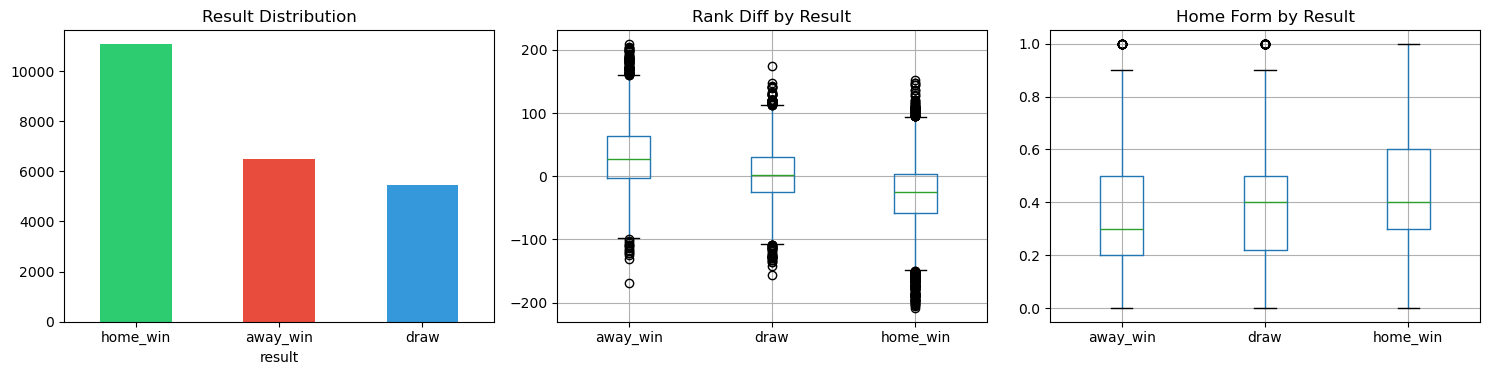

EDA plots saved!


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# result distribution
matches_final['result'].value_counts().plot(kind='bar', ax=axes[0], 
                                             color=['#2ecc71','#e74c3c','#3498db'])
axes[0].set_title('Result Distribution')
axes[0].tick_params(axis='x', rotation=0)

# rank diff by result
matches_final.boxplot(column='rank_diff', by='result', ax=axes[1])
axes[1].set_title('Rank Diff by Result')
axes[1].set_xlabel('')

# home form by result
matches_final.boxplot(column='home_form', by='result', ax=axes[2])
axes[2].set_title('Home Form by Result')
axes[2].set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.savefig('../data/processed/eda_plots.png', dpi=150)
plt.show()
print("EDA plots saved!")

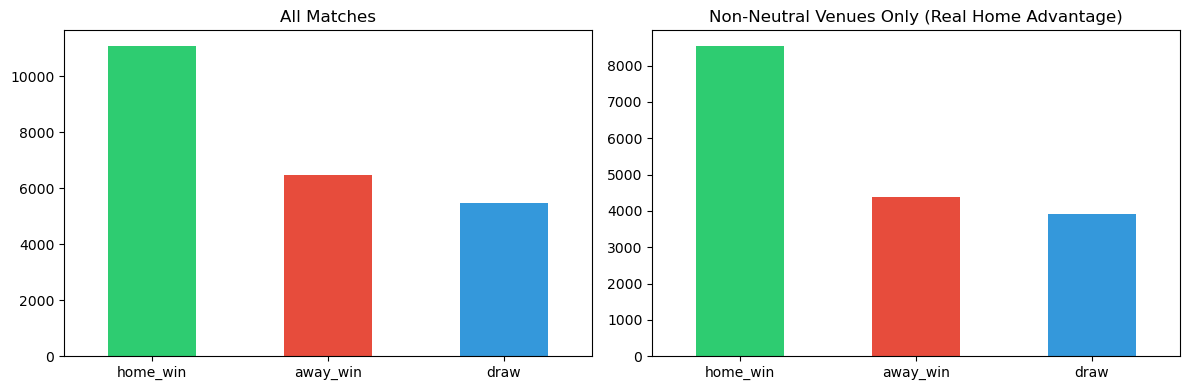

All matches:
result
home_win    11081
away_win     6477
draw         5463
Name: count, dtype: int64

Non-neutral only:
result
home_win    8544
away_win    4372
draw        3925
Name: count, dtype: int64


In [29]:
# result distribution for non-neutral venues only (real home advantage matches)
non_neutral = matches[matches['neutral'] == False]['result'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# all matches
matches['result'].value_counts().plot(kind='bar', ax=axes[0], 
                                       color=['#2ecc71','#e74c3c','#3498db'])
axes[0].set_title('All Matches')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_xlabel('')

# non-neutral only
non_neutral.plot(kind='bar', ax=axes[1], 
                 color=['#2ecc71','#e74c3c','#3498db'])
axes[1].set_title('Non-Neutral Venues Only (Real Home Advantage)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('../data/processed/neutral_vs_all.png', dpi=150)
plt.show()

print("All matches:")
print(matches['result'].value_counts())
print("\nNon-neutral only:")
print(non_neutral)

**Result Distribution (All Matches vs Non-Neutral Venues)**

The first chart confirms a well-known phenomenon in football — home advantage is real. Across all 23,021 matches in our dataset, home wins account for nearly half of all results. When we isolate non-neutral venue matches (where a team is genuinely playing at home), the home win proportion increases further, validating that the home/away label carries genuine signal in non-neutral contexts. However since FIFA World Cup 2026 matches are played at neutral venues across USA, Canada and Mexico, this home advantage does not apply to our prediction target. The home/away label in our dataset is therefore treated as an administrative convention rather than a true indicator of venue advantage, and no home advantage signal is encoded into our final feature set.


**Rank Diff by Result**

The box plot reveals that rank difference is our strongest predictive feature. When the home team wins, the median rank difference is negative — meaning the home team tends to be ranked higher (lower number = better rank). Conversely when the away team wins, the median rank difference is positive, indicating the away team was the stronger side. Draws cluster closest to zero, confirming that evenly matched teams are more likely to share points. The clear separation between result categories validates rank_diff as a meaningful signal for the model.

**Home Form by Result**

Recent form shows a subtler but consistent pattern. Home teams that win tend to have slightly higher recent form scores than those who lose, though the overlap between categories is larger than for rank difference. This suggests form is a supporting signal rather than a primary predictor — valuable in combination with rank and head to head history but not decisive on its own.